In [1]:
#Carga de datos
import pandas as pd
import json
import numpy as np
from comun.Server_PD import download_dataframe_minio

from collections import Counter
import re

#Graficas
import seaborn as sns
import matplotlib.pyplot as plt
import isodate

from itertools import combinations
import ast
import os
from pathlib import Path

import comun.analisisutils as utils
import comun.filter_and_divide_data as filter


c:\Trabajos\c2526-R1\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
print(os.getcwd())

c:\Trabajos\c2526-R1\src\analisis


# Carga de datos

In [3]:
#Arreglamos la ruta
root = Path().resolve().parents[1]  
os.chdir(root)
print(os.getcwd())
df = filter.download_latest_extraction_correct(0)
df_fil = filter.download_latest_extraction_correct(2)
print(f'Tamaño de dataset sin filtrar: {len(df)}')
print(f'Tamaño de dataset filtrado: {len(df_fil)}')

C:\Trabajos\c2526-R1
Filtrando datos, con filtro de subtitulos
Numero de videos con duraciones atípicas: 2263
Numero de videos sin información textual: 766
Numero de videos con poca representación de generos: 1000
Guardamos aproximadamente  11 % de videos sin subtitulos para niños y adultos
La longitud antes de filtrar los subtitulos era  19103 y ahora es  6442
Tenemos  1273  videos de niños y  5169  videos de adultos
Hay  1151  videos de niños con subtítulos
Partiendo de 22896, se han eliminado 3793, resultando en: 19103 filas
Tamaño de dataset sin filtrar: 22896
Tamaño de dataset filtrado: 6442


# Transformamos y añadimos columnas

In [4]:
#Densidad de habla
df['Palabras_Por_Minuto'] = df.apply(utils.calcular_wpm, axis=1)
df['Palabras_Por_Minuto'] = round(df['Palabras_Por_Minuto'], 2)
df_fil['Palabras_Por_Minuto'] = df_fil.apply(utils.calcular_wpm, axis=1)
df_fil['Palabras_Por_Minuto'] = round(df_fil['Palabras_Por_Minuto'], 2)

# Creamos un diccionario con un df por cada genero

In [5]:
diccionario_generos = utils.division_generos(df)
for clave in diccionario_generos:
    print(clave, ":", len(diccionario_generos[clave]))
    df = diccionario_generos[clave]
    df_Adult, df_Kids = utils.division_edad(df)
    print(f'    Adultos: {len(df_Adult)}')
    print(f'    Kids: {len(df_Kids)}')
#Los 0 se deben a que youtube Kids y youtube Movies
print(f'-----------------------------')
diccionario_generos_fil = utils.division_generos(df_fil)
for clave in diccionario_generos:
    print(clave, ":", len(diccionario_generos_fil[clave]))
    df_fil = diccionario_generos_fil[clave]
    df_Adult, df_Kids = utils.division_edad(df_fil)
    print(f'    Adultos: {len(df_Adult)}')
    print(f'    Kids: {len(df_Kids)}')

Film & Animation : 2432
    Adultos: 236
    Kids: 2196
Autos & Vehicles : 209
    Adultos: 102
    Kids: 107
Music : 2059
    Adultos: 406
    Kids: 1653
Pets & Animals : 390
    Adultos: 56
    Kids: 334
Sports : 1173
    Adultos: 97
    Kids: 1076
Short Movies : 0
    Adultos: 0
    Kids: 0
Travel & Events : 292
    Adultos: 125
    Kids: 167
Gaming : 1352
    Adultos: 250
    Kids: 1102
Videoblogging : 0
    Adultos: 0
    Kids: 0
People & Blogs : 1945
    Adultos: 1155
    Kids: 790
Comedy : 65
    Adultos: 34
    Kids: 31
Entertainment : 3829
    Adultos: 495
    Kids: 3334
News & Politics : 1688
    Adultos: 1664
    Kids: 24
Howto & Style : 1582
    Adultos: 307
    Kids: 1275
Education : 5058
    Adultos: 625
    Kids: 4433
Science & Technology : 620
    Adultos: 318
    Kids: 302
Nonprofits & Activism : 202
    Adultos: 52
    Kids: 150
Movies : 0
    Adultos: 0
    Kids: 0
Anime/Animation : 0
    Adultos: 0
    Kids: 0
Action/Adventure : 0
    Adultos: 0
    Kids: 0
Classics

Vemos que hay muchos generos que no tienen ninguna aparicion. No los vamos a tener en cuenta para hacer las graficas. Vamos a eliminar aquellos generos con 0 apariciones. (Esto se debe a que muchos géneros son exclusivos de Youtube Movies)

Filtrado 2 de base reduce a cero aquellos géneros con menos de 500 apariciones, para ser eliminados. 

In [18]:
#Elimina los dfs sin información, es decir, tienen len == 0
for diccionario in (diccionario_generos, diccionario_generos_fil):
    for key in list(diccionario.keys()):
        if len(diccionario[key]) == 0:
            del diccionario[key]


In [7]:
print(f'Generos sin filtrado: {diccionario_generos.keys()}')
print(f'Generos con filtrado: {diccionario_generos_fil.keys()}')

Generos sin filtrado: dict_keys(['Film & Animation', 'Autos & Vehicles', 'Music', 'Pets & Animals', 'Sports', 'Travel & Events', 'Gaming', 'People & Blogs', 'Comedy', 'Entertainment', 'News & Politics', 'Howto & Style', 'Education', 'Science & Technology', 'Nonprofits & Activism'])
Generos con filtrado: dict_keys(['Film & Animation', 'Music', 'Sports', 'Gaming', 'People & Blogs', 'Entertainment', 'News & Politics', 'Howto & Style', 'Education', 'Science & Technology'])



En este notebook de analisis nos vamos a centrar principalmente en los dataframes filtrados debido a que estos se van a utilizar para el entrenamiento de modelos. Sin embargo, también se mostrará información sobre los dataframes sin filtrar para observar los cambios producidos. 

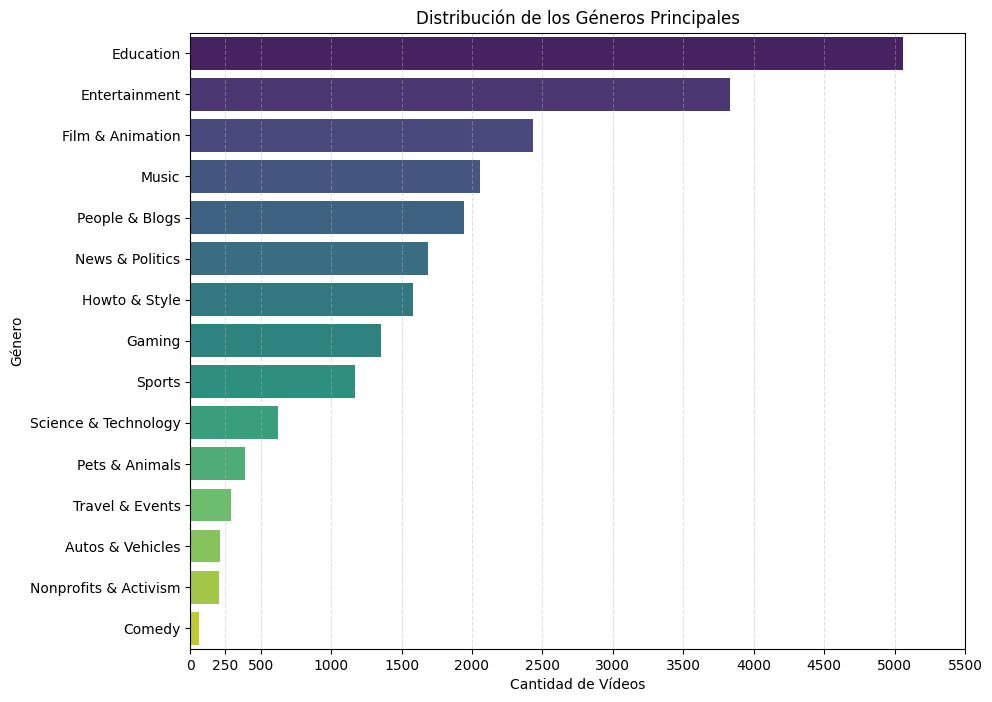

In [8]:
utils.gráfico_frecuencias_generos(diccionario_generos=diccionario_generos)

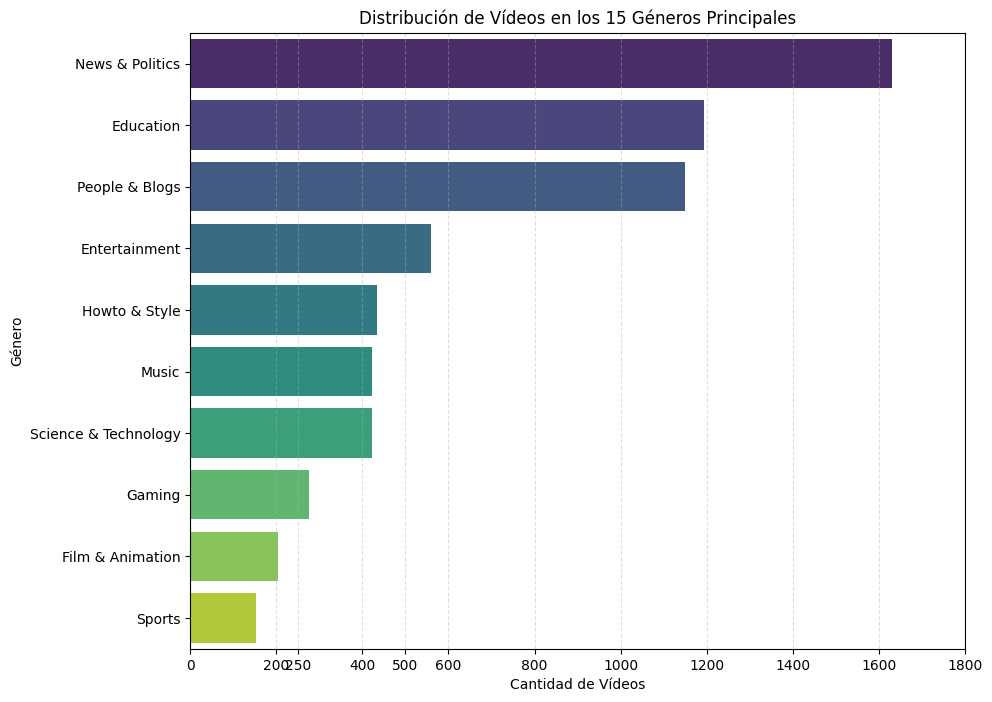

In [9]:
utils.gráfico_frecuencias_generos(diccionario_generos=diccionario_generos_fil)

El dataframe sin filtrar tiene 15 posibles géneros, mientras que el filtrado tiene 10 debido a que el filtrado elimina géneros con menos de 500 apariciones.

Es destacable que géneros como educación y entretenimiento pierden muchos vídeos al ser filtrados debido a que al ser principalmente de niños y no contar con subtitulos son eliminados. De esta forma, "New & Politics" se convierte en el género con más apariciones. 

Aquellos vídeos con más apariciones son News & Politics, Education y People & Blogs. Mientras que los más minoritarios son Sports, Film & Animation y Gaming


# Análisis no textual

## Duracion

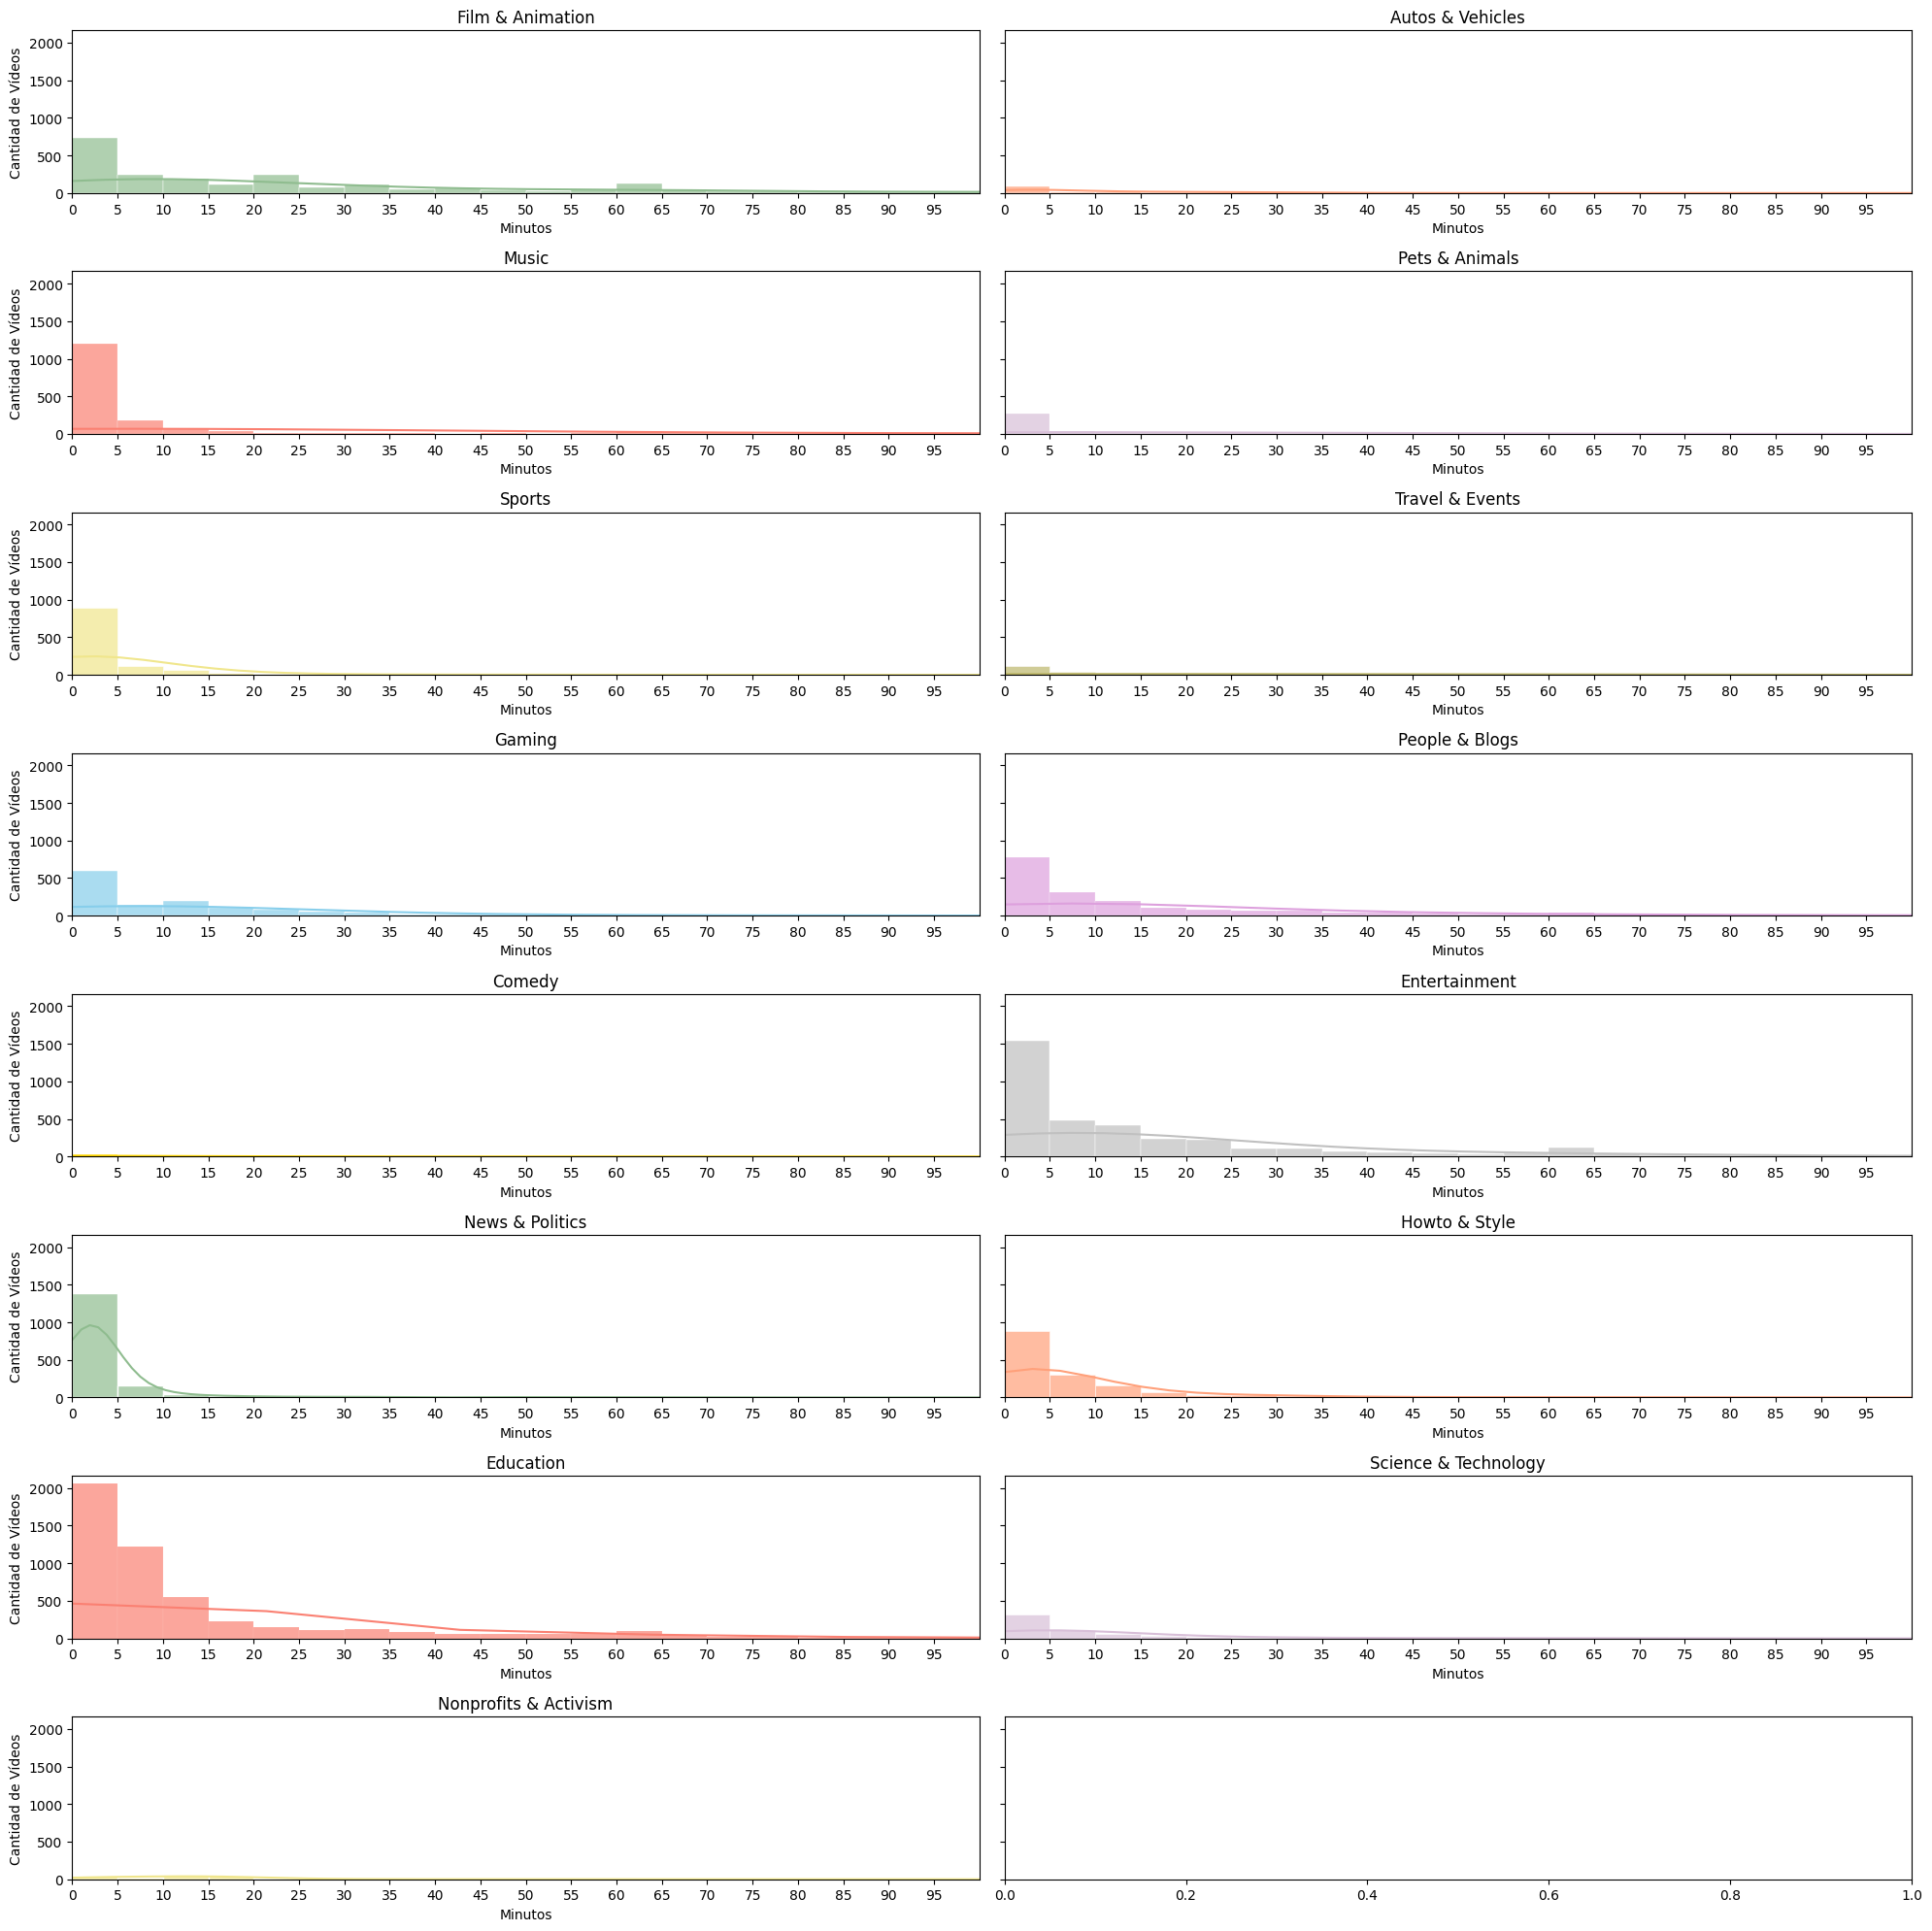

In [9]:
# Configuración
fig, ax = plt.subplots(8, 2, figsize=(20, 20), sharey=True)

ax = ax.flatten()
colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki', 'skyblue', 'plum', "gold", 'silver', 
           'darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki', 'skyblue', 'plum', "gold", 'silver']
i = 0
for clave, valor in list(diccionario_generos.items()):
    utils.graficar_histograma_duracion(diccionario_generos[clave], clave, ax[i], colores[i])
    i += 1

plt.tight_layout()
plt.show()

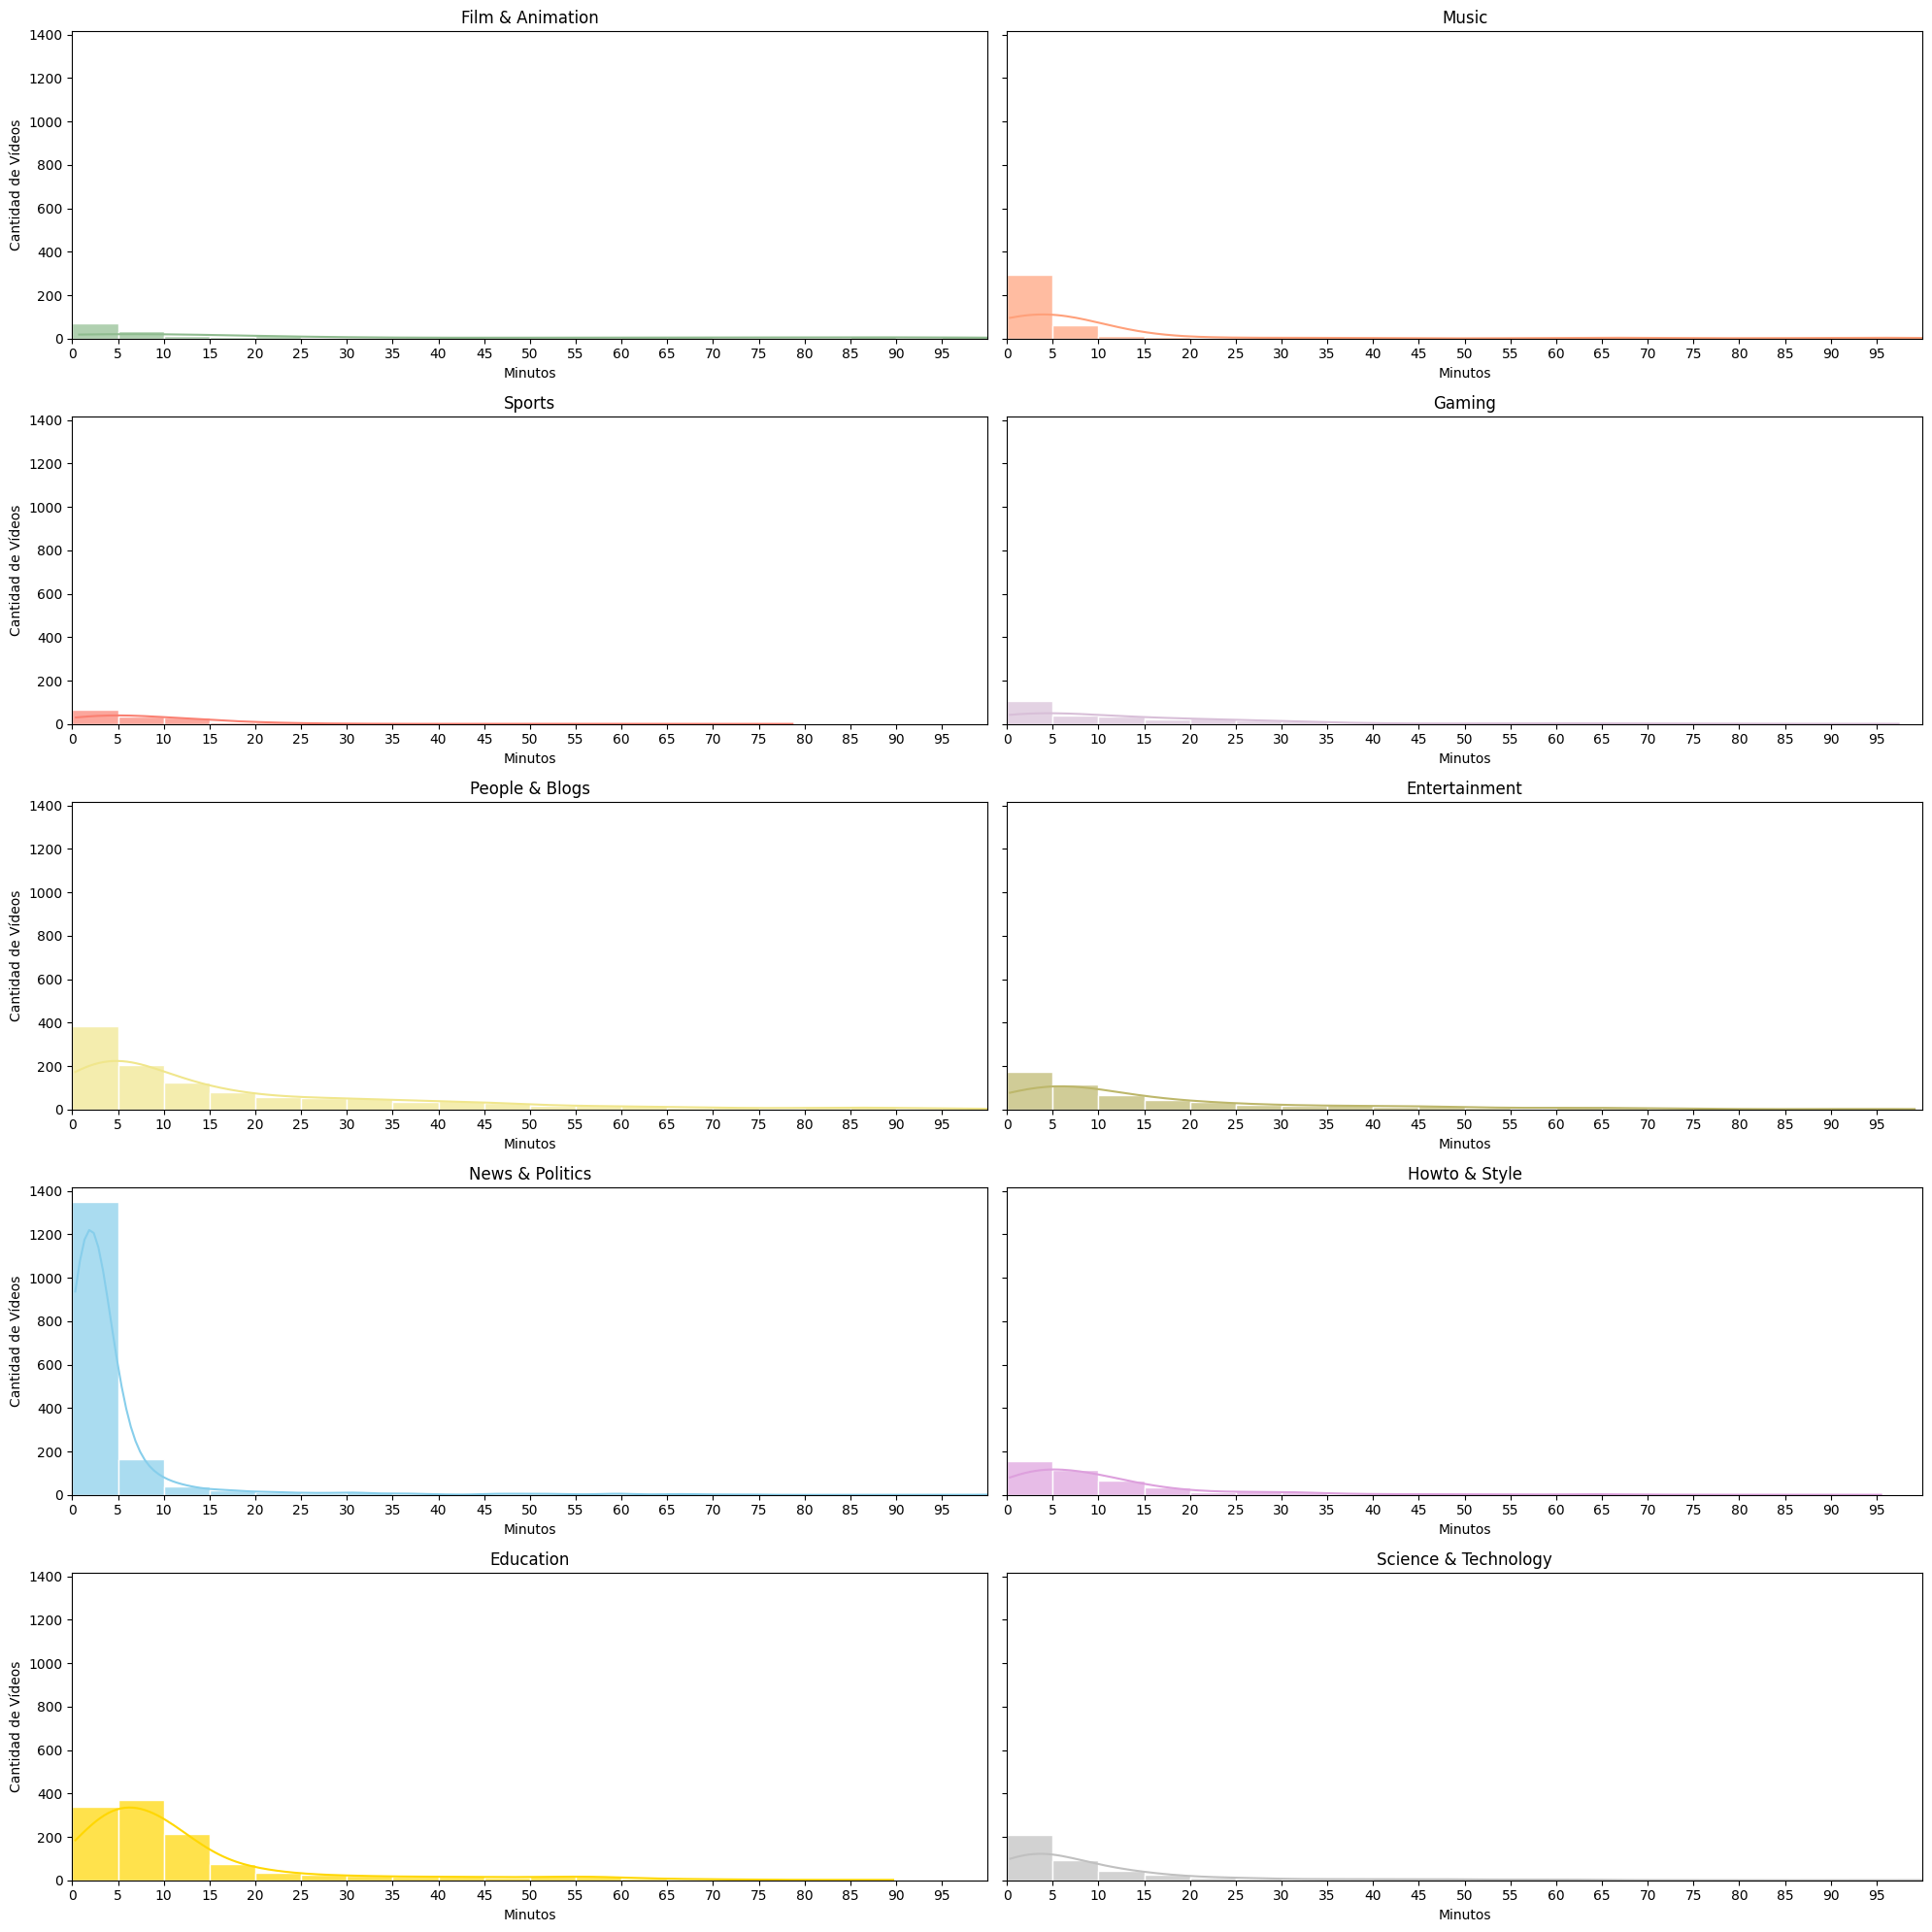

In [47]:
# Configuración
fig, ax = plt.subplots(5, 2, figsize=(20, 20), sharey=True)

ax = ax.flatten()
colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki', 'skyblue', 'plum', "gold", 'silver', 
           'darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki', 'skyblue', 'plum', "gold", 'silver']
i = 0
for clave, valor in list(diccionario_generos_fil.items()):
    utils.graficar_histograma_duracion(diccionario_generos_fil[clave], clave, ax[i], colores[i])
    i += 1

plt.tight_layout()
plt.show()

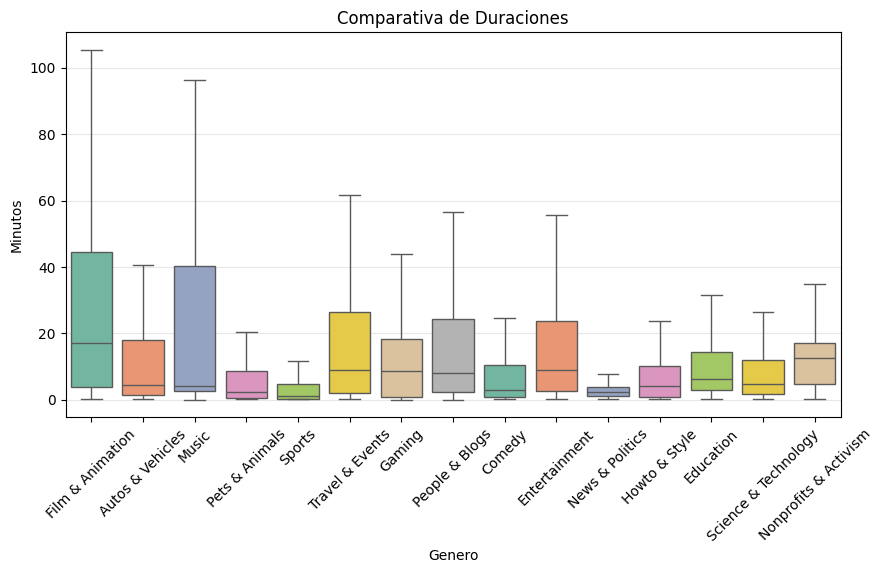

In [10]:
df_grafica = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_generos.items()
])

plt.figure(figsize=(10, 5))
sns.boxplot(x='Genero', y='Duracion', data=df_grafica, palette='Set2', showfliers=False)  

plt.xticks(rotation=45)
plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.grid(axis = "y", alpha = 0.3)
plt.show()

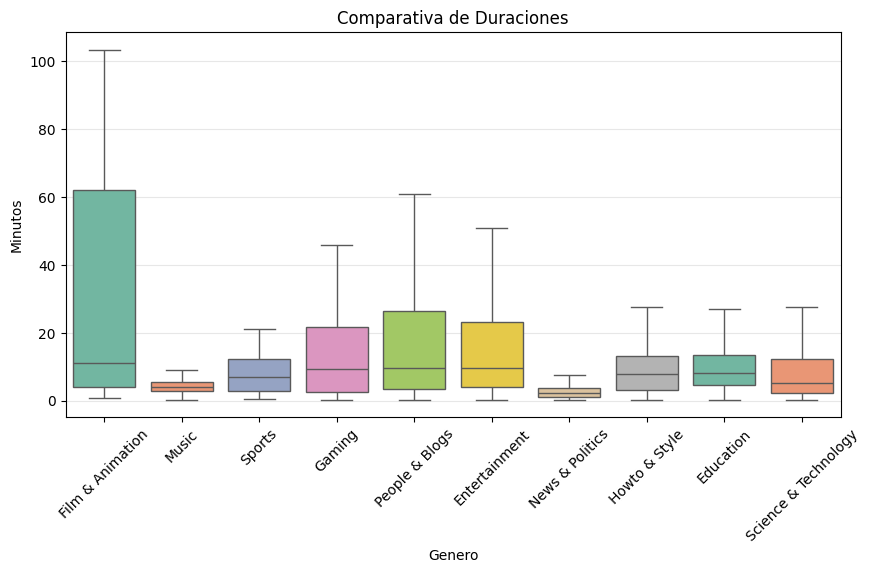

In [48]:
df_grafica = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_generos_fil.items()
])

plt.figure(figsize=(10, 5))
sns.boxplot(x='Genero', y='Duracion', data=df_grafica, palette='Set2', showfliers=False)  

plt.xticks(rotation=45)
plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.grid(axis = "y", alpha = 0.3)
plt.show()

Con los gráficos de boxplot e histograma obtenidos se pueden sacar las siguientes conclusiones. 

A un primer vistazo, todos los vídeos suelen tener la misma duración (mediana), aproximadamente 10 min. A excepción de music y News & Politics que parece que tienen videos con duraciones mucho menores entorno a los 5 minutos o menos. 

También las cajas de Music y News & Politics son pequeñas mostrando que la mayoría de los videos tienen duraciones similares. Por otro lado, Film and Animation es la caja más grande y con más varianza, con vídeos de hasta 1 hora. El resto de cajas parecen tener tamaños bastante similares. 

## Densidad de habla

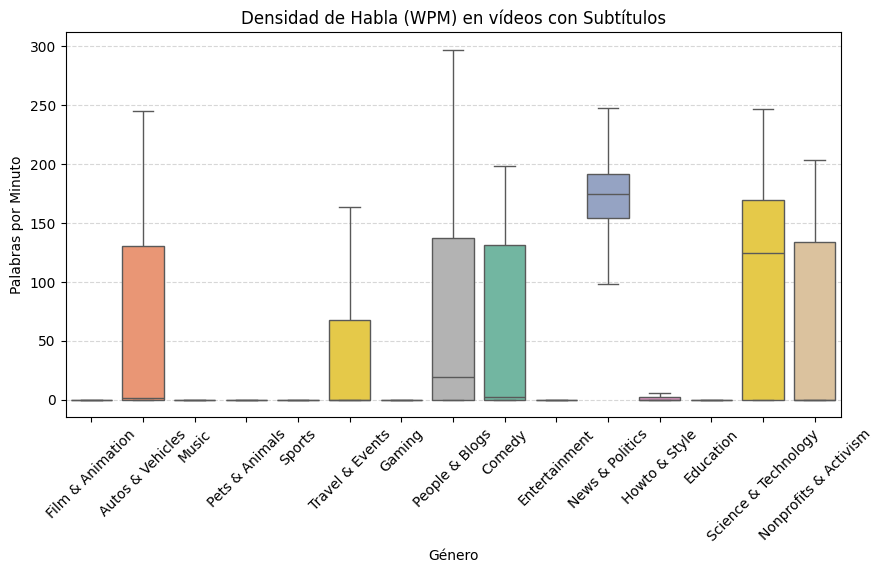

In [11]:
df_grafica_subs = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_generos.items()
])

plt.figure(figsize=(10, 5))

#No mostramos los outliers para que se vea más limpio
sns.boxplot(x='Genero', y='Palabras_Por_Minuto', data=df_grafica_subs, palette='Set2', showfliers=False)


plt.title('Densidad de Habla (WPM) en vídeos con Subtítulos')
plt.xlabel('Género')
plt.ylabel('Palabras por Minuto')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

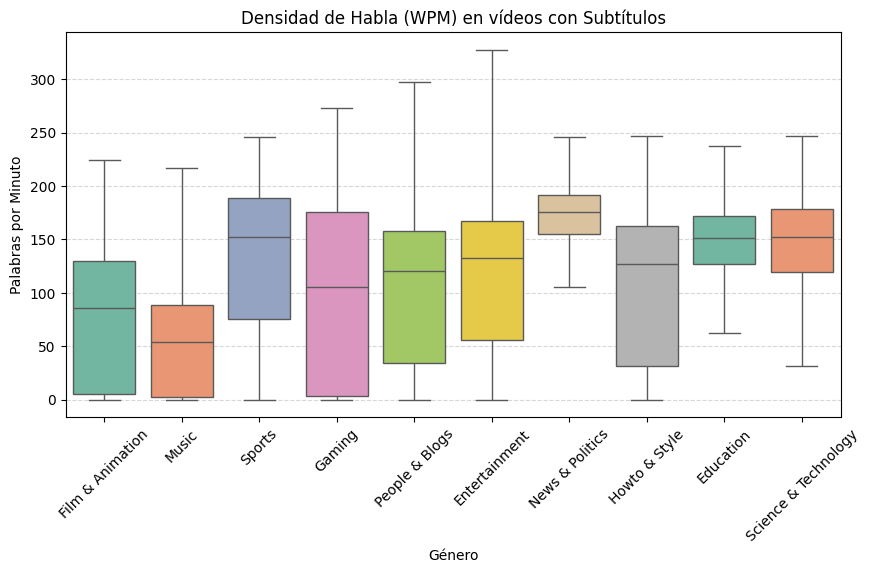

In [12]:
df_grafica_subs = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_generos_fil.items()
])

plt.figure(figsize=(10, 5))

#No mostramos los outliers para que se vea más limpio
sns.boxplot(x='Genero', y='Palabras_Por_Minuto', data=df_grafica_subs, palette='Set2', showfliers=False)


plt.title('Densidad de Habla (WPM) en vídeos con Subtítulos')
plt.xlabel('Género')
plt.ylabel('Palabras por Minuto')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

En sin filtrar dado que mucho de los datos de densidad de habla = 0 porque faltan subtitulos, nos dan cajas casi invisibles. 

Habiendo solucionado esto en el dataframe filtrado se puede observar que existen géneros con bastante varianza como Film & Animation, Howto & Style, Gaming o Sports. Mientras que hay otras más comprimidas como News & Politics o Education. En general son cajas más grandes que en el caso de duración. News & Politics es la que tiene con más seguridad mayor densidad de habla aunque Entertaiment y Sports tienen vídeos llegan o incluso superan las 250 palabras por minuto. Por otro lado, Film & Animation, Music o Gaming tienen las menores densidades de habla, seguramente se deba a momentos exclusivamente visuales o sin diálogo prolongados. 

Cabe destacar que videos como Education y Science & Technology parecen tener densidades muy similares, tal vez, por similitud de conceptos u objetivos. 

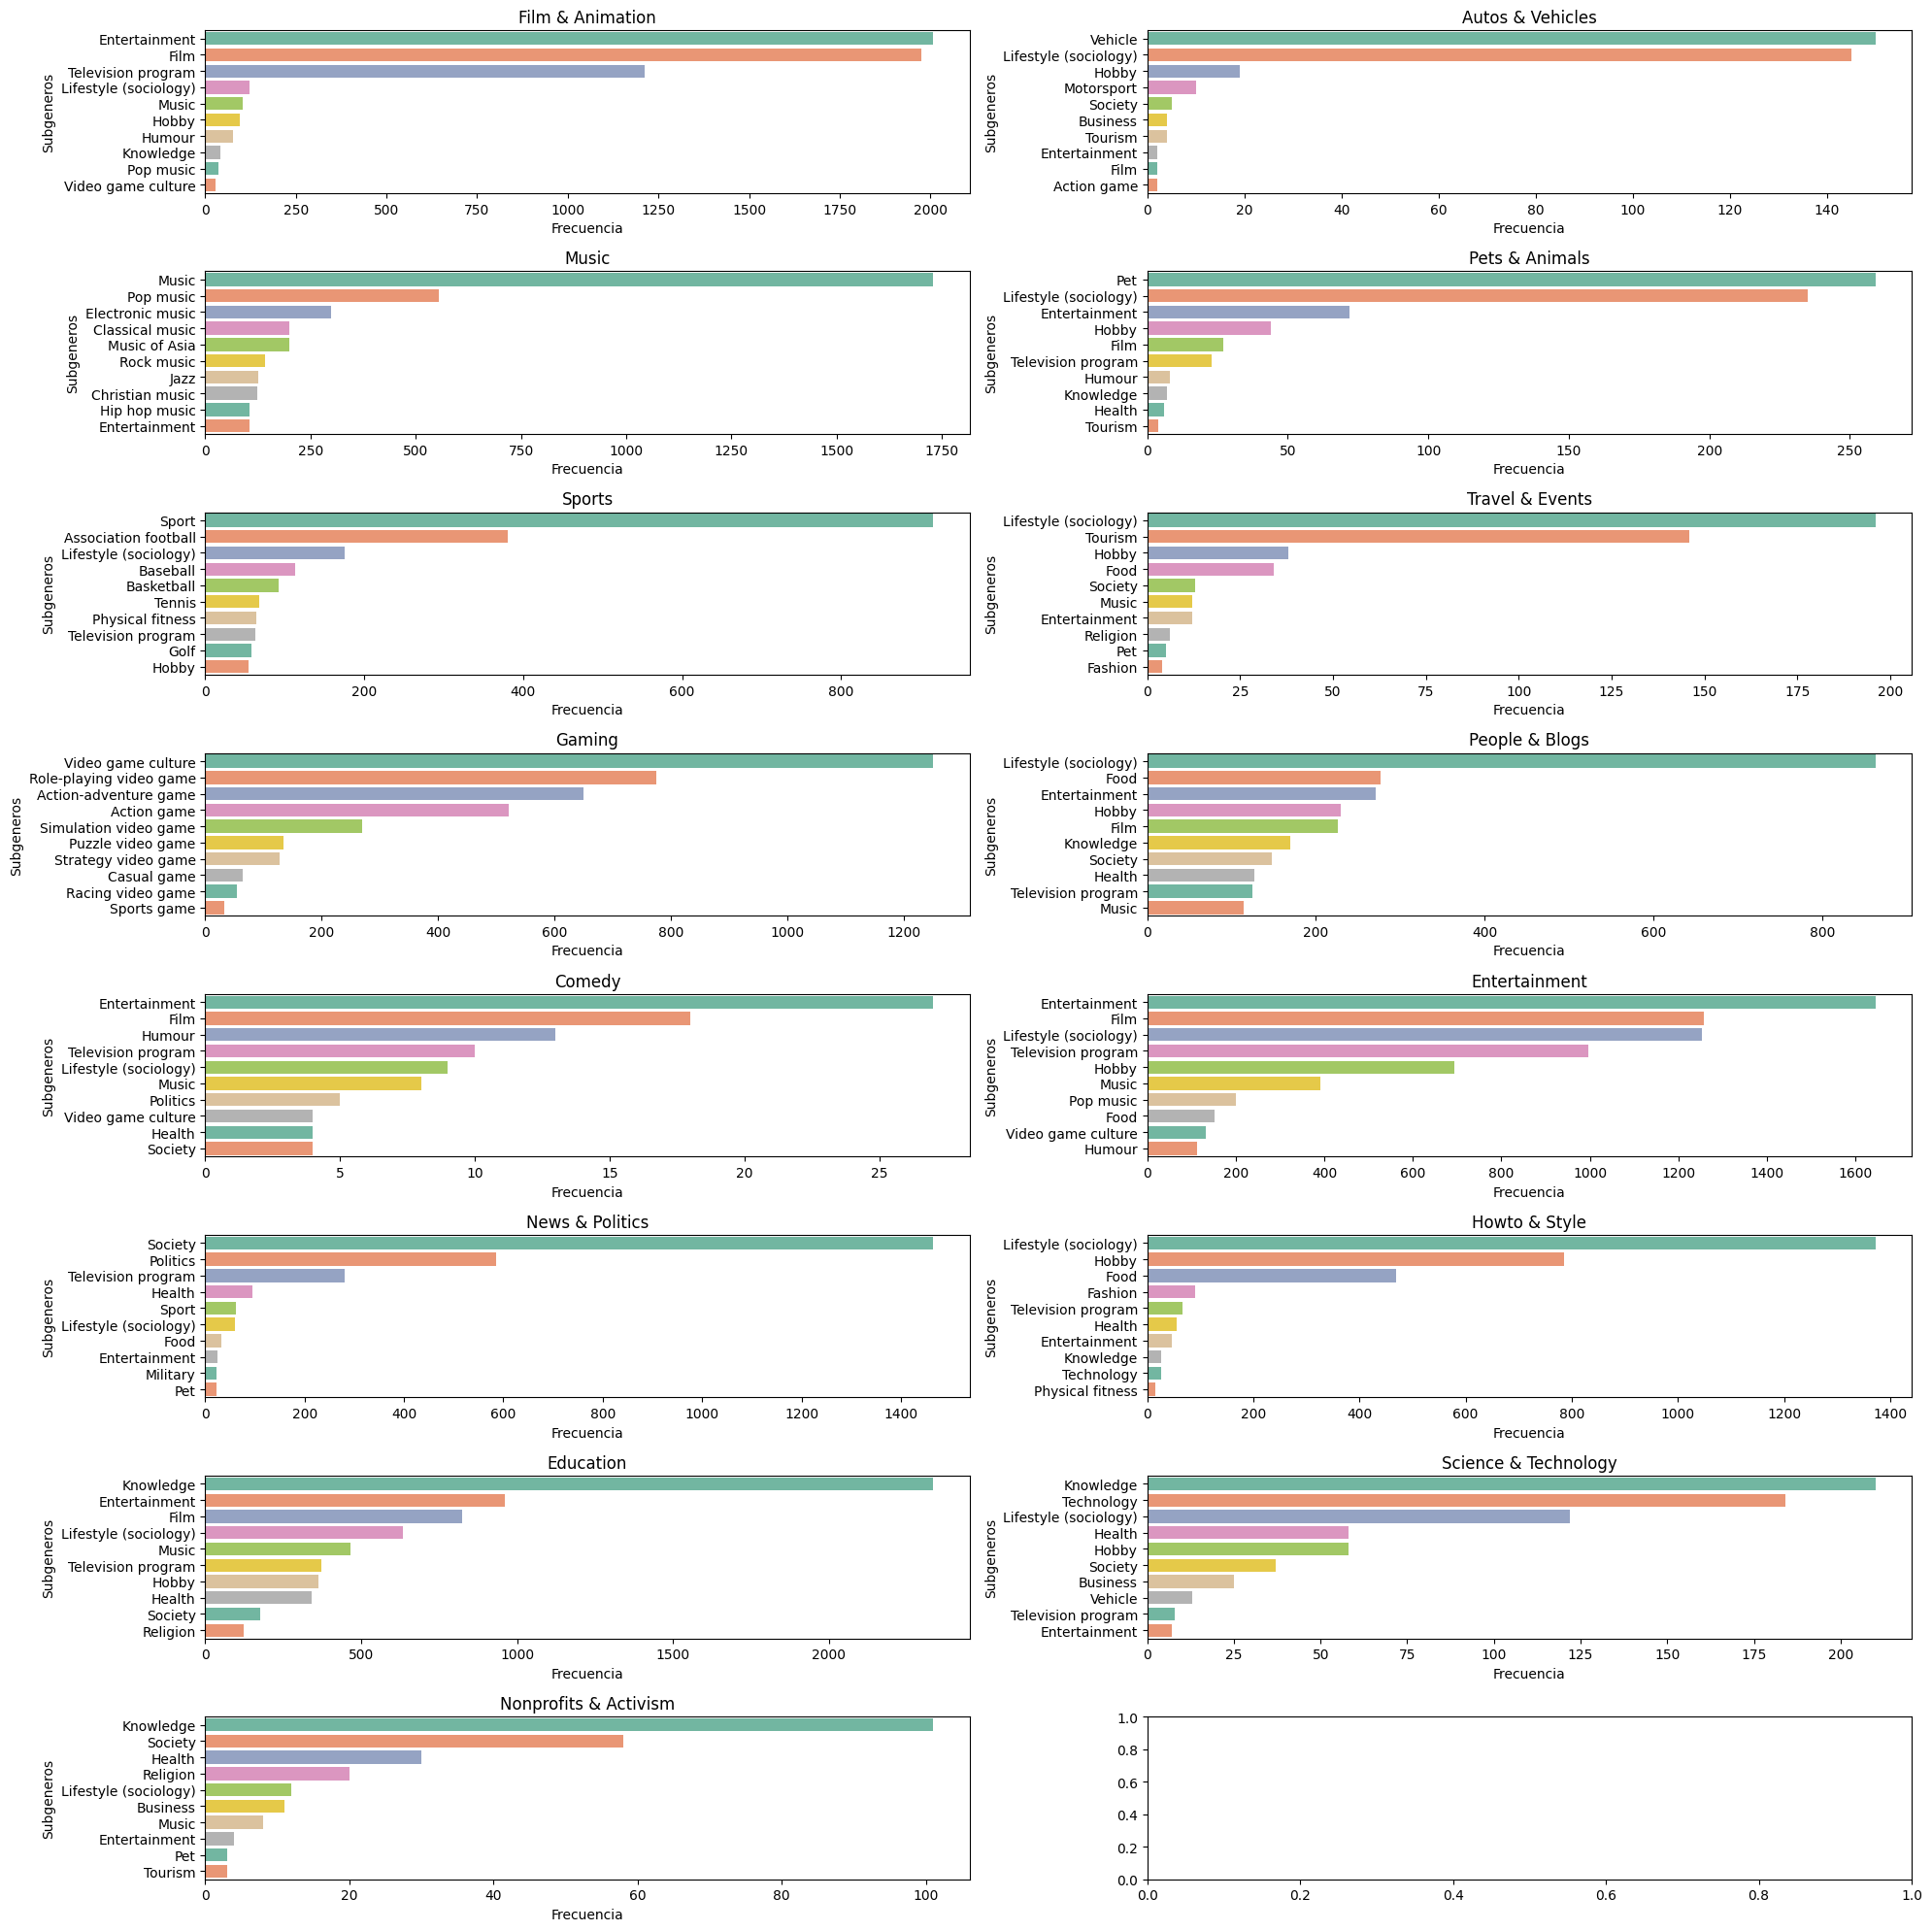

In [13]:
fig, ax = plt.subplots(8,2, figsize = (20,20))
ax = ax.flatten()
i = 0
for keys, values in list(diccionario_generos.items()):
    utils.graficar_top_generos(diccionario_generos[keys], keys, ax[i], "Set2", "Subgeneros")
    i = i+1
plt.tight_layout()

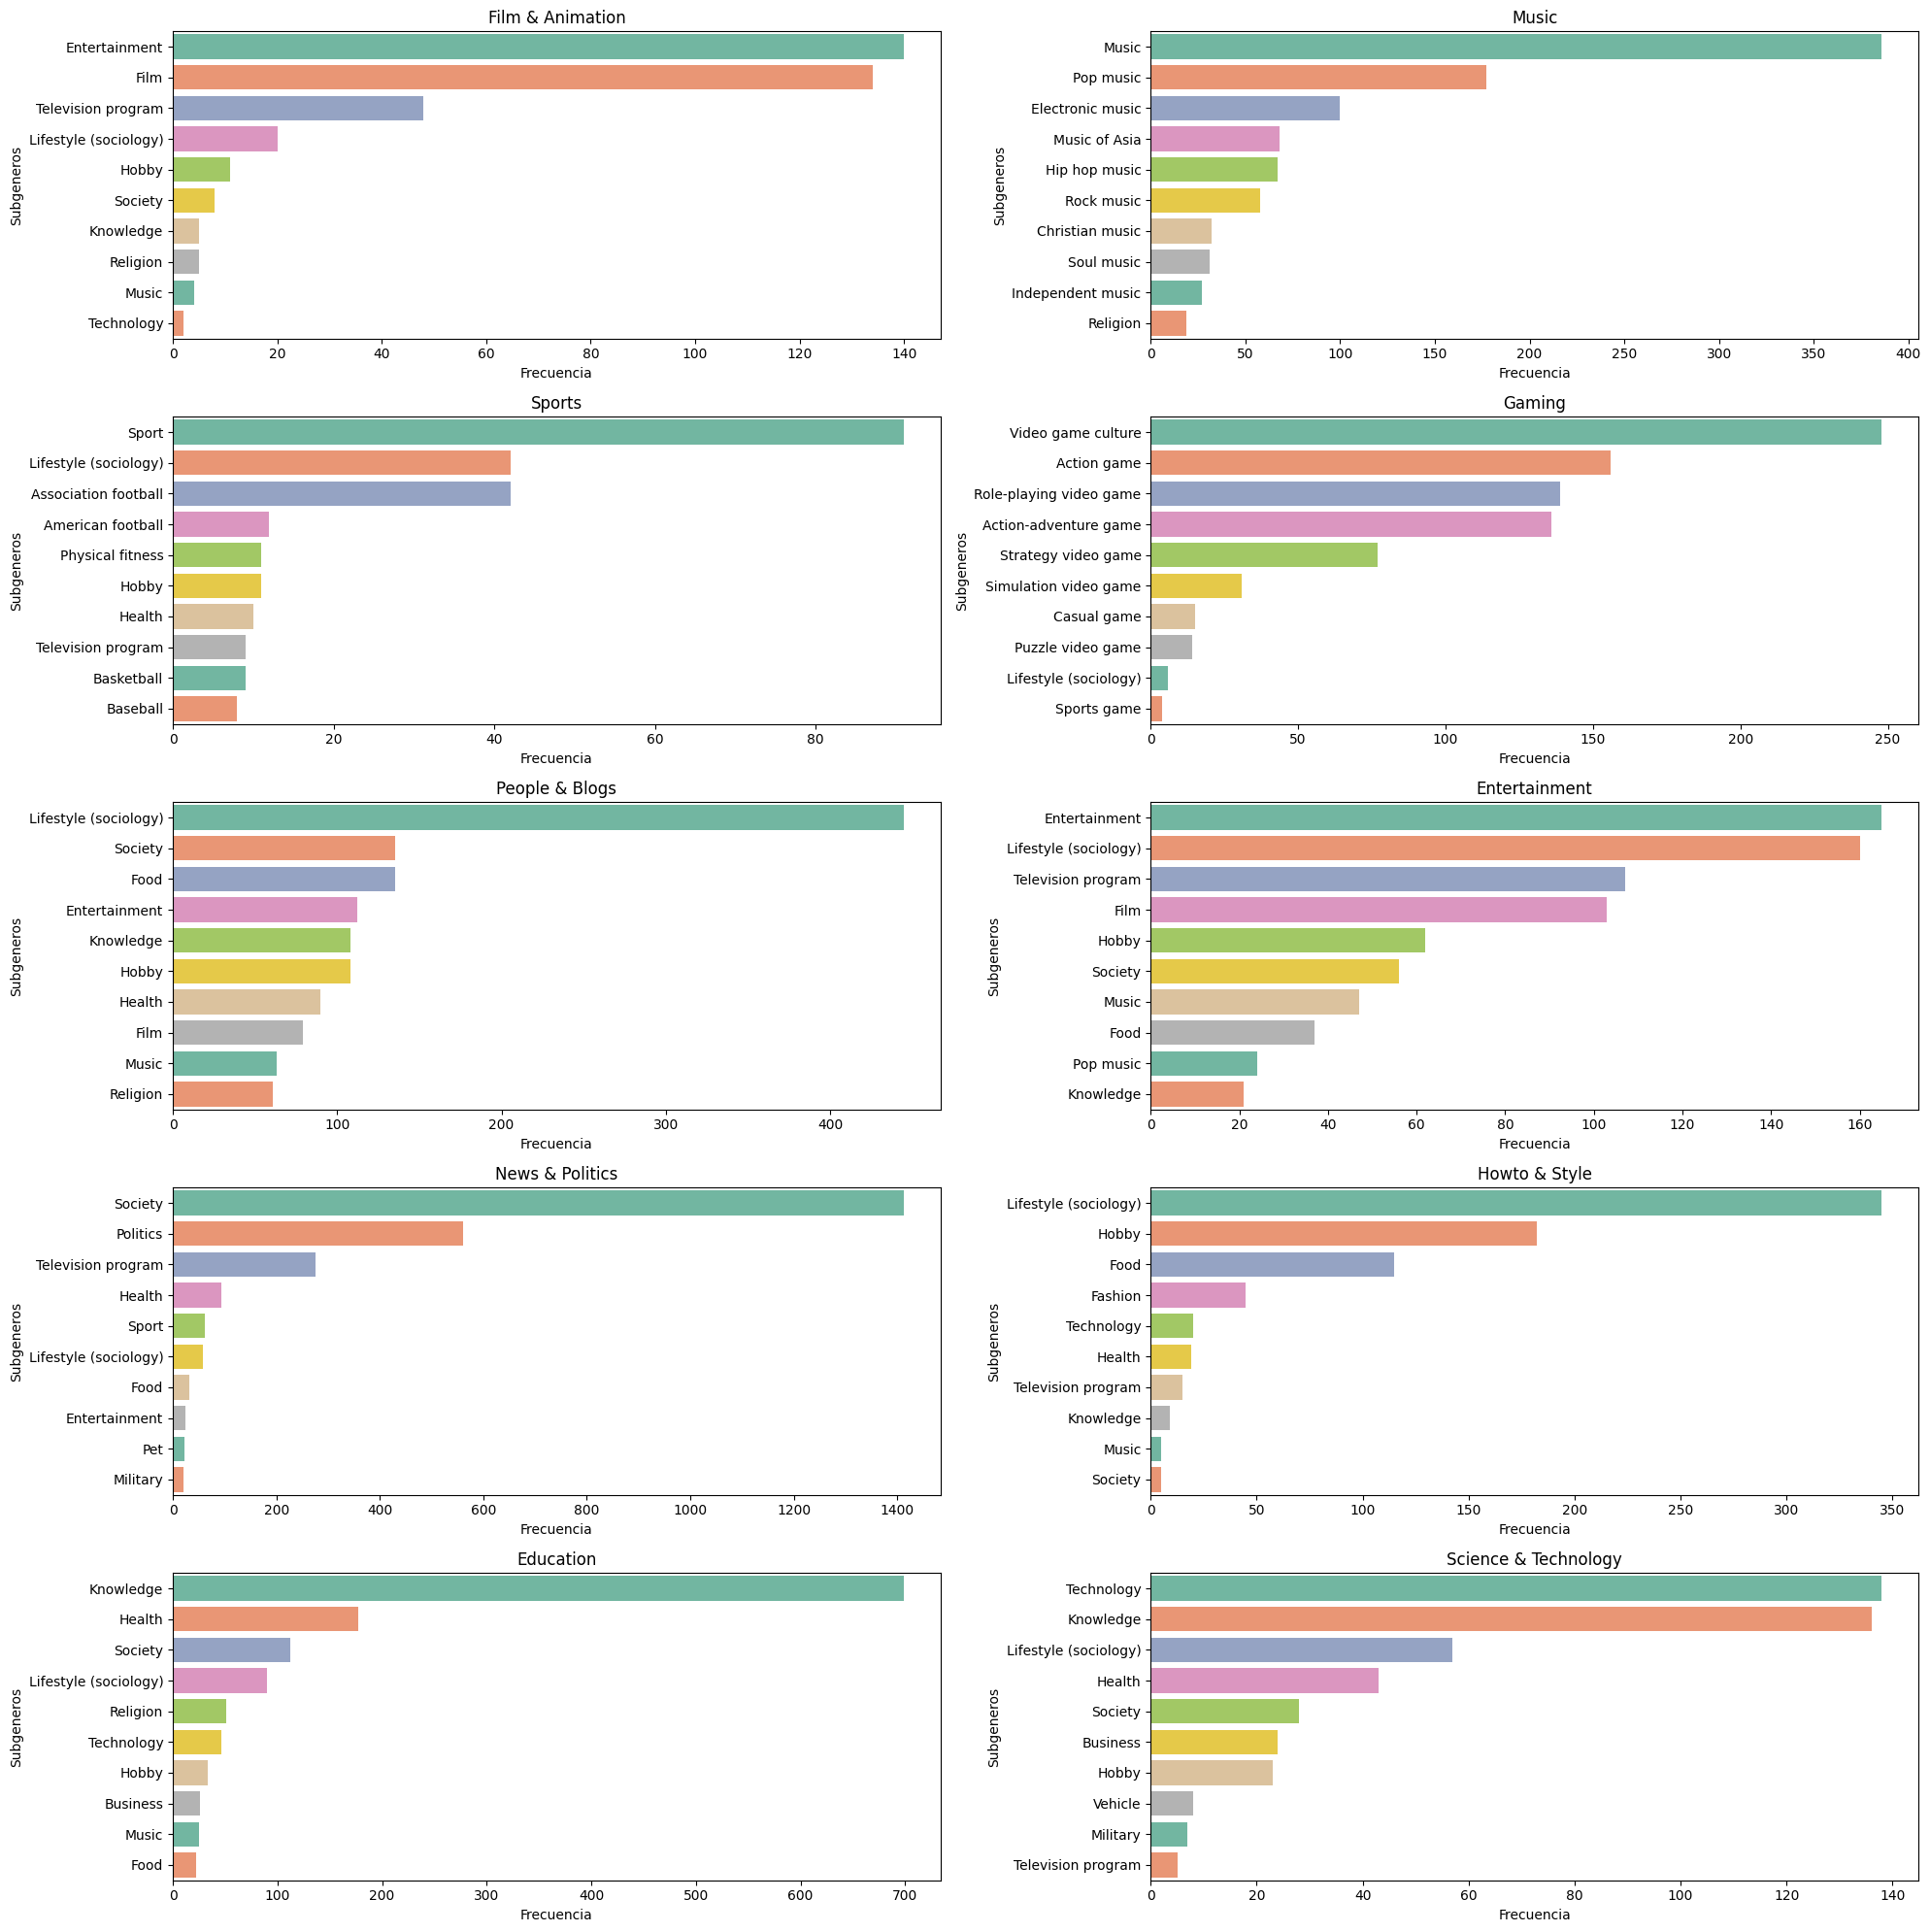

In [52]:
fig, ax = plt.subplots(5,2, figsize = (20,20))
ax = ax.flatten()
i = 0
for keys, values in list(diccionario_generos_fil.items()):
    utils.graficar_top_generos(diccionario_generos_fil[keys], keys, ax[i], "Set2", "Subgeneros")
    i = i+1
plt.tight_layout()

Con estos datos podemos sacar como conclusión que los subgéneros son extremadamente similares al género que pertenecen. Por ejemplo, Music tiene distitos tipos de musica o Gaming sus subgeneros incluyen la palabra game principalmente. A parte todos los géneros pareen tener siempre de 1 a 3 subgéneros que acumulan el 50% o más de las apariciones. 

Esto implica que no deberíamos utilizar la columna Subgeneros para identificar los géneros porque en su mayoría parece ser que el subgénero y el género son el mismo (Education == Knowledge, Science & Technology == Technology, Entertainment == Entertainment). Sin embargo, si son utilizados en el problema de clasificación por edad pueden servir para aumentar la seguridad al tratar con géneros. 
 

# Analisis Textual

## Título

In [19]:
diccionario_tf_titulos = {}
diccionario_tf_titulos_fil = {}

for clave, df_genero in diccionario_generos_fil.items():
    diccionario_tf_titulos_fil[clave] = utils.tfidf_ngrams_titles(df_genero, "Titulo")

for clave, df_genero in diccionario_generos.items():
    diccionario_tf_titulos[clave] = utils.tfidf_ngrams_titles(df_genero, "Titulo")


In [20]:
common_terms = utils.common_terms_dictionary(diccionario_tf_titulos, "Titulo")

common_terms.sort_values("Score_Std", ascending=False).head(10)

,Titulo,Score_Film & Animation,Score_Autos & Vehicles,Score_Music,Score_Pets & Animals,Score_Sports,Score_Travel & Events,Score_Gaming,Score_People & Blogs,Score_Comedy,Score_Entertainment,Score_News & Politics,Score_Howto & Style,Score_Education,Score_Science & Technology,Score_Nonprofits & Activism,Score_Std,Score_Total


In [21]:
common_terms = utils.common_terms_dictionary(diccionario_tf_titulos_fil, "Titulo")

common_terms.sort_values("Score_Std", ascending=False).head(10)

,Titulo,Score_Film & Animation,Score_Music,Score_Sports,Score_Gaming,Score_People & Blogs,Score_Entertainment,Score_News & Politics,Score_Howto & Style,Score_Education,Score_Science & Technology,Score_Std,Score_Total
0,new,2.656020,4.914617,2.815469,7.370610,8.615619,5.298392,24.164874,3.878868,3.632143,4.712189,6.385282,68.058800
1,2026,1.368488,8.616112,5.550473,4.676157,10.790387,7.903628,12.791270,4.515102,11.482658,5.038667,3.650242,72.732942
2,vs,1.312033,1.594712,2.981628,4.670067,7.243913,4.817630,1.926689,2.592833,4.892915,4.747127,1.894003,36.779549


Parece ser que casi no hay terminos comunes entre los títulos de los distintos géneros a excepción de palabras extremadamente genéricas como new, 2026 o vs. 

Ahora vamos a comparar las palabras que aparecen exclusivamente en un genero de entre dos que son pueden tener solapaciones. Algunos de estos géneros podrían ser Science & Technology con Education, Gaming con Enterainment, People & Blogs con Howto Style o Film & Animation con Entertainment. 

In [22]:
entertainment_only, gaming_only = utils.exclusive_terms(diccionario_tf_titulos_fil["Entertainment"], 
    diccionario_tf_titulos_fil["Gaming"], "Titulo")

education_only, science_only = utils.exclusive_terms(diccionario_tf_titulos_fil["Education"], diccionario_tf_titulos_fil["Science & Technology"], "Titulo")
People_only, how_only = utils.exclusive_terms(diccionario_tf_titulos_fil["People & Blogs"], diccionario_tf_titulos_fil["Howto & Style"], "Titulo")


print("Gaming")
print(gaming_only.head(5))
print("Entertainment")
print(entertainment_only.head(5))
print("--------------")
print("Education")
print(education_only.head(5))
print("Science & Technology")
print(science_only.head(5))
print("--------------")
print("People")
print(People_only.head(5))
print("Howto & Style")
print(how_only.head(5))
print("--------------")

Gaming
        Titulo      Score
225  minecraft  13.399303
357   windrose   7.255215
335   tutorial   3.904149
39        arma   3.380970
157      guide   3.339047
Entertainment
       Titulo     Score
60       asmr  7.710241
405      kids  5.007312
345      home  4.544729
579  reaction  4.396668
190       day  4.386076
--------------
Education
           Titulo      Score
835  khan academy  22.202852
834          khan  22.202852
69        academy  22.202852
563       english  19.202053
417         crash  16.172920
Science & Technology
          Titulo     Score
232      machine  6.624633
271  numberphile  5.220821
59      building  4.542684
339        river  3.805753
396   technology  3.269400
--------------
People
      Titulo     Score
852     life  9.915214
490  episode  7.209293
889     love  6.426492
487       ep  6.398523
979   mother  6.208685
Howto & Style
        Titulo     Score
337  old house  5.213858
193     flower  4.157321
454     stitch  3.893758
266       knit  3.79085

Entre Gaming y Enternteinment podemos observar que los gaming engloban términos de videojuegos ("minecraft", "guide", "tutorial") mientras que entertainment tiene términos más variados ("love", "reaction", "asmr")

Entre Education y Science & Technology podemos observar que education se repiten términos pedagogicos más enfocados a niños ("academy") mientras que Science utiliza terminos más especificos y técnicos en comparación ("machine", "building")

Entre People y Howto & Style podemos observar que People incluye términos bastante generales ("life", "love", "episode"), mientras que Howto muestra términos más específicos y relacionados con casas o manualidades ("old house", "yarn", "stitch")

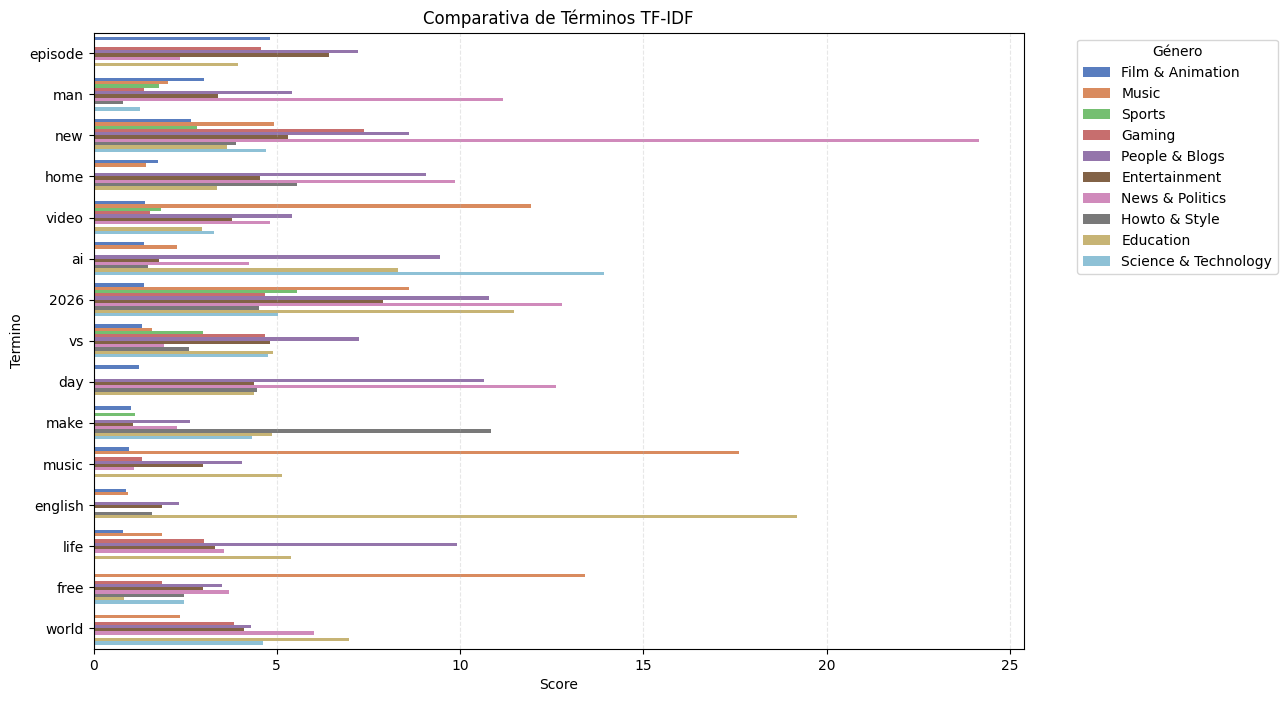

In [23]:
#Seleccionamos 4 generos
generos_a_comparar = diccionario_generos_fil.keys()

plt.figure(figsize=(12, 8))
utils.comparativa_terminos(generos_a_comparar, diccionario_tf_titulos_fil)
plt.show()

Comparando globalmente los términos de los títulos podemos observar que los términos con mayor score tienen tanto géneros muy marcados (music - music, education - kids, News & Politics - new, Howto & Style - make), como mezclados (best, 2026, world).
Por tanto, títulos parece ser útil para poder encontrar patrones que relacionen título con género.



Ahora hacemos un analisis de topics más profundo con bertopic para ver si podemos encontrar diferencias semánticas importantes en los títulos sobre su temática

In [24]:
#BERTOPIC SOLUCIONAR
topic_model_titulo, df_bertopic_titulo, temas_bertopic_titulo = utils.analizar_bertopic_dict(diccionario_generos_fil, "Titulo")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
dicc_bertopic_titulo = utils.division_generos(df_bertopic_titulo)

<Figure size 1000x600 with 0 Axes>

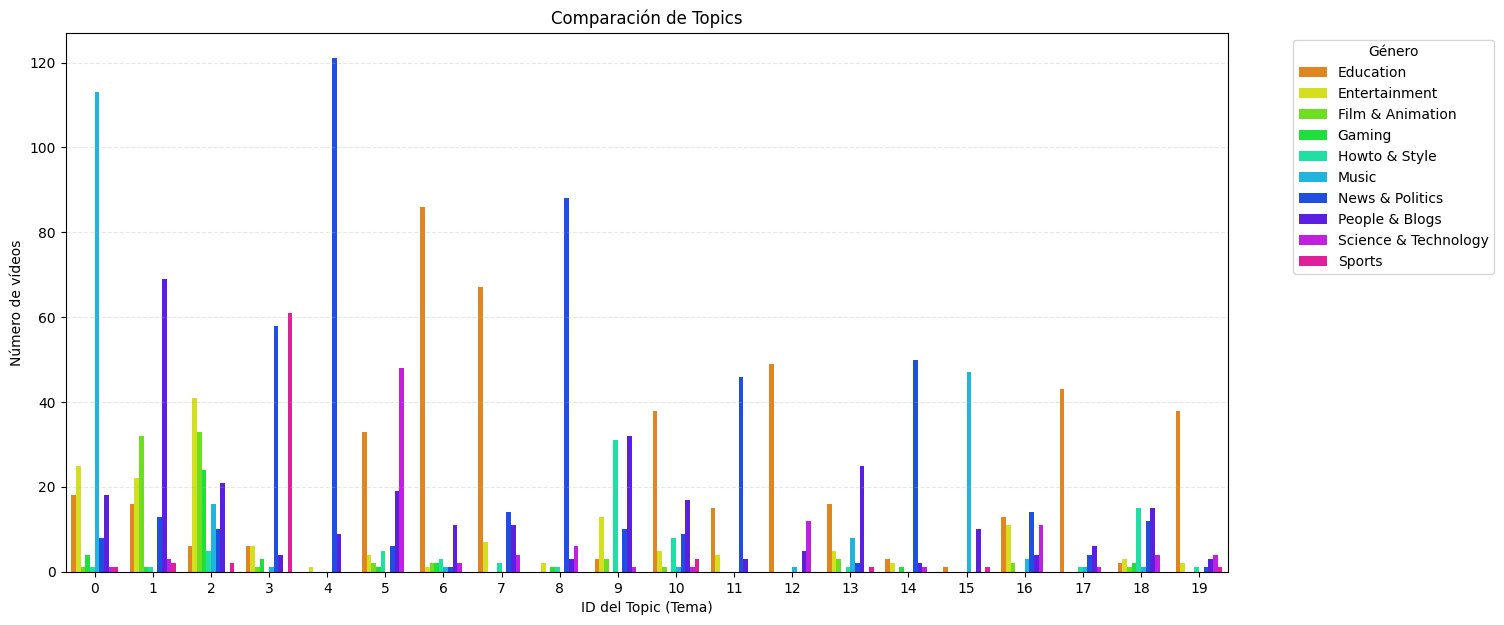

In [26]:
generos_a_comparar = dicc_bertopic_titulo.keys()

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_titulo, generos_a_comparar, "Titulo")
plt.show()

In [27]:
topic_info = topic_model_titulo.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2952,-1_the_to_of_and,"[the, to, of, and, in, for, how, with, on, is]",[I Know My Defender Lives: The Job 19:25 Secre...
1,0,190,0_music_song_official_jazz,"[music, song, official, jazz, rock, audio, vid...",[【BSS】AI Music《Beautiful Obsession 美麗的執念》Moder...
2,1,159,1_her_she_he_ceo,"[her, she, he, ceo, his, was, mother, wife, ma...","[She CHEATED with Her FATHER-IN-LAW, [Multi SU..."
3,2,158,2_episode_film_movie_horror,"[episode, film, movie, horror, short, kids, di...",[Daniel's Obstacle Course | NEW Episode! | Sea...
4,3,140,3_sports_league_arsenal_baseball,"[sports, league, arsenal, baseball, championsh...",[Breeders' Cup 2022: Juvenile Turf (FULL RACE)...
5,4,131,4_shooting_man_woman_arrested,"[shooting, man, woman, arrested, suspect, shot...",[Tanglewood school shooting suspect pleads gui...
6,5,118,5_ai_agent_cloud_agents,"[ai, agent, cloud, agents, google, how, for, c...",[The hidden cost of AI hallucinations at enter...
7,6,109,6_english_learn_grammar_listening,"[english, learn, grammar, listening, speaking,...","[Learn English Grammar: The Sentence, 100 Dail..."
8,7,105,7_finance_capital_khan_markets,"[finance, capital, khan, markets, academy, mar...",[The housing price conundrum | Current Economi...
9,8,101,8_weather_forecast_storms_weekend,"[weather, forecast, storms, weekend, friday, h...","[First Alert Weather Extra 4-16-26 segment #3,..."


Simplemente observando algunos de los tópicos que se generan podemos hacernos una idea de que si que hay diferencias semánticas significativas.
Por ejemplo, Education domina los tópicos 4,6 (Aprender ingles, Finanzas); News & Politics domina los tópicos 5,12 (Tiempo y armas) o Music el 1 y el 17 (Música, Ritmo). 

## Titulo canal


In [28]:
for clave, df_genero in diccionario_generos_fil.items():
    print(clave, df_genero.shape)

Film & Animation (208, 14)
Music (419, 14)
Sports (151, 14)
Gaming (277, 14)
People & Blogs (1151, 14)
Entertainment (564, 14)
News & Politics (1630, 14)
Howto & Style (426, 14)
Education (1196, 14)
Science & Technology (420, 14)


In [29]:
diccionario_tf_titulo_canal = {}

for clave, df_genero in diccionario_generos_fil.items():
    diccionario_tf_titulo_canal[clave] = utils.tfidf_ngrams_titles(df_genero, "Titulo_canal")

**Terminos comunes**

In [30]:
common_terms = utils.common_terms_dictionary(diccionario_tf_titulo_canal, "Titulo_canal")

common_terms.sort_values("Score_Std", ascending=False).head(20)

,Titulo_canal,Score_Film & Animation,Score_Music,Score_Sports,Score_Gaming,Score_People & Blogs,Score_Entertainment,Score_News & Politics,Score_Howto & Style,Score_Education,Score_Science & Technology,Score_Std,Score_Total


**Terminos exclusivos**

In [34]:
entertainment_only, gaming_only = utils.exclusive_terms(diccionario_tf_titulo_canal["Entertainment"], 
    diccionario_tf_titulo_canal["Gaming"], "Titulo_canal")

education_only, science_only = utils.exclusive_terms(diccionario_tf_titulo_canal["Education"], diccionario_tf_titulo_canal["Science & Technology"], "Titulo_canal")
People_only, how_only = utils.exclusive_terms(diccionario_tf_titulo_canal["People & Blogs"], diccionario_tf_titulo_canal["Howto & Style"], "Titulo_canal")


print("Gaming")
print(gaming_only.head(5))
print("Entertainment")
print(entertainment_only.head(5))
print("--------------")
print("Education")
print(education_only.head(5))
print("Science & Technology")
print(science_only.head(5))
print("--------------")
print("People")
print(People_only.head(5))
print("Howto & Style")
print(how_only.head(5))
print("--------------")

Gaming
      Titulo_canal      Score
27          gaming  11.099510
23            game   9.927978
57          milsim   7.457651
60       minecraft   6.000000
22  froggycrossing   5.000000
Entertainment
    Titulo_canal     Score
156     official  8.868039
256        world  8.310200
79       history  7.456035
145      mrbeast  7.000000
240           tv  6.661576
--------------
Education
            Titulo_canal      Score
78           crashcourse  65.000000
181         khan academy  63.961058
180                 khan  63.961058
184  khanacademymedicine  41.000000
269             nptelhrd  26.000000
Science & Technology
        Titulo_canal      Score
160        stratvert  14.433757
86             kevin  14.433757
87   kevin stratvert  14.433757
110      minuteearth   9.000000
131      numberphile   9.000000
--------------
People
    Titulo_canal      Score
280           lý  12.863912
329         news  10.607172
98         drama  10.412233
424      stories   9.515959
425        story   7.

Después de este análisis vamos a deternos en buscar términos exclusivos y comunes porque vemos una tendencia a que no existen terminos comunes a todos los géneros y ya podemos entender mejor las diferencias entre géneros que podrían confundirse como similares. 

Por ejemplo, Entretenimiento parece ir más términos más generales ("world") o canales lúdicos variados ("Mr Beast"). Por otro lado, gaming parece estar principalmente enfocado en videojuegos. Por otro lado, educacion trata temas divulgativos a un público general o escolar ("khan academy"), mientras que Science y Technology está pensado para un público más adulto y profesional ("kevin stratvert"). También, people cuenta historias ("drama", "stories") y how to & style sobre manualidades ("crochet")


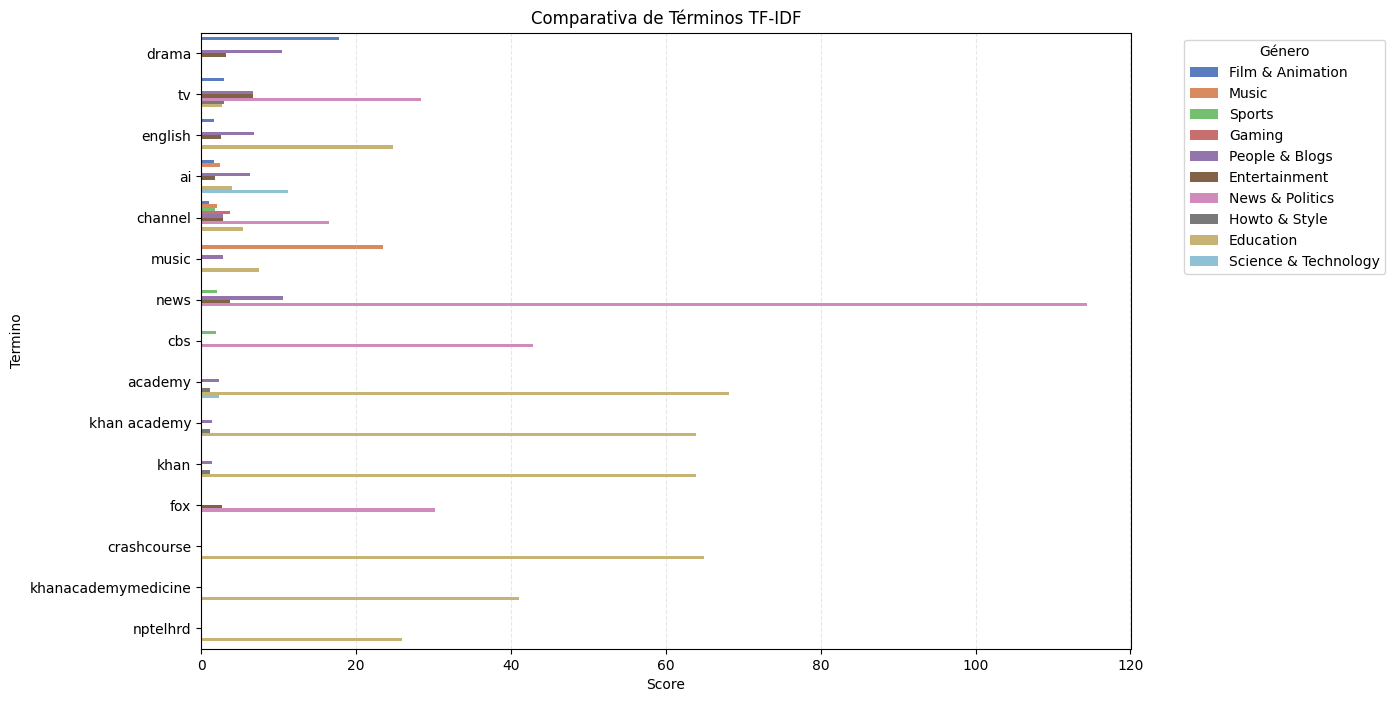

In [35]:
#Seleccionamos 4 generos
generos_a_comparar = diccionario_tf_titulo_canal.keys()

plt.figure(figsize=(12, 8))
utils.comparativa_terminos(generos_a_comparar, diccionario_tf_titulo_canal)
plt.show()

Viendo los títulos del canal, reafirmamos que no hay solapación y que cada canal tiene asignado un género en la mayor parte de casos. 

In [41]:
topic_model_titulo_canal, df_bertopic_titulo_canal, temas_bertopic_titulo_canal = utils.analizar_bertopic_dict(diccionario_generos_fil, "Titulo_canal")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [42]:
dicc_bertopic_titulo_canal = utils.division_generos(df_bertopic_titulo_canal)


<Figure size 1000x600 with 0 Axes>

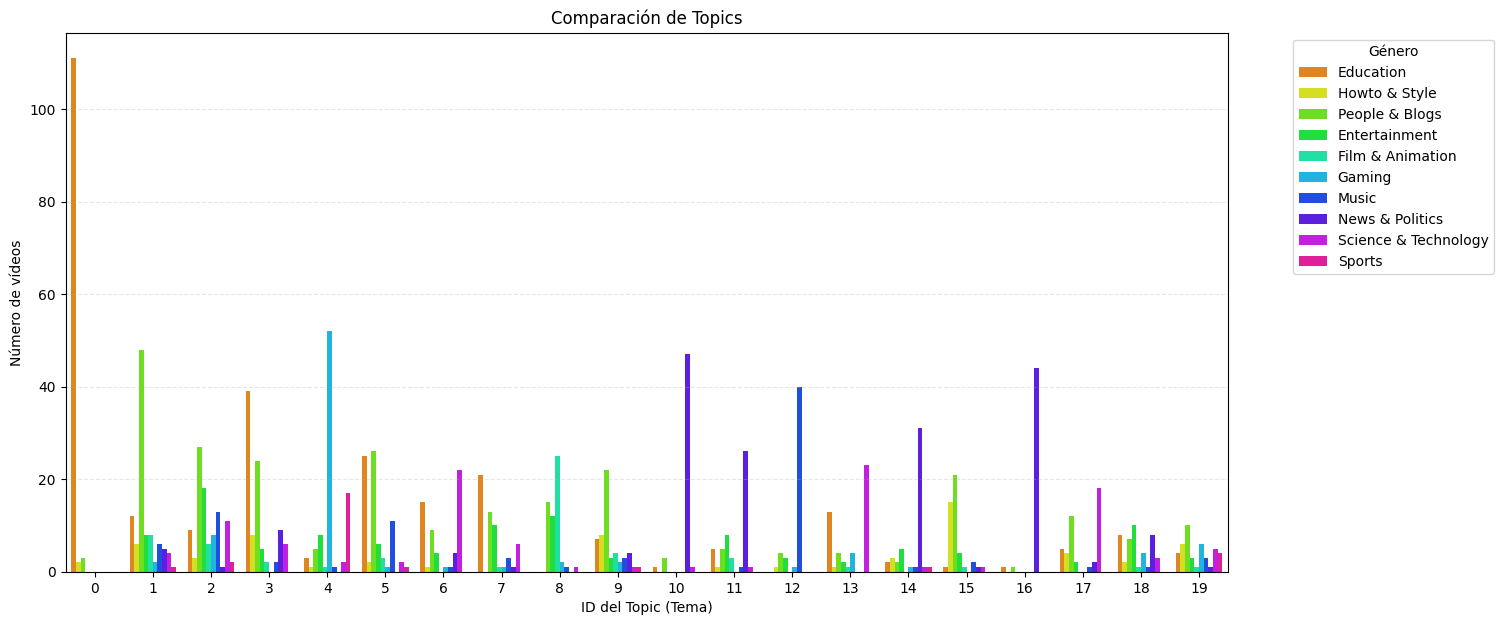

In [43]:
generos_a_comparar = dicc_bertopic_titulo_canal.keys()

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_titulo_canal, generos_a_comparar, "Titulo_canal")
plt.show()

In [44]:
topic_info = topic_model_titulo_canal.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1687,-1_lý_space_the_america,"[lý, space, the, america, and, talktv, wcia, t...","[America's Test Kitchen, Patent Law for Engine..."
1,0,116,0_khan_academy_india_physics,"[khan, academy, india, physics, educators, fep...","[Khan Academy, Khan Academy, Khan Academy]"
2,1,100,1_china_chinese_african_dazi,"[china, chinese, african, dazi, taehyung, 达子, ...","[The story of African wives in China, The stor..."
3,2,98,2_star_vision_majestic_know,"[star, vision, majestic, know, darkness, light...","[No One Know Your Darkness, No One Know Your D..."
4,3,95,3_daily_smart_cents_market,"[daily, smart, cents, market, two, validation,...","[Market Validation Lab, Market Validation Lab,..."
5,4,90,4_gaming_games_game_minecraft,"[gaming, games, game, minecraft, golf, gamer, ...","[allBash Gaming Videos, Magic Gaming, Magic Ga..."
6,5,77,5_holy_bible_jesus_wisdom,"[holy, bible, jesus, wisdom, christ, saint, pr...","[The Saints bible study and Prayer Network, Ho..."
7,6,57,6_dr_health_clinic_healthcare,"[dr, health, clinic, healthcare, snaplogic, me...","[Brescia MScFN Dietetic Practicum, Indisputabl..."
8,7,56,7_psychology_psych2go_quiet_brain,"[psychology, psych2go, quiet, brain, asapscien...","[Psych2Go, DARK SIDE PSYCHOLOGY, Quiet Psychol..."
9,8,56,8_movie_film_cinema_boxoffice,"[movie, film, cinema, boxoffice, scenes, movie...","[Boxoffice ANIMATION ☆ Movie Scenes, Boxoffice..."


Podemos sacar las mismas conclusiones que con títulos, semanticamente cada canal parece tener diferencias signficiativas por género. Aunque está información es mucho menos fiable ya que los canales suelen tener nombres como de 1 a 5 palabras lo cual este analizador de texto no puede sacar tanto contexto y un tfidf podría ser más eficiente. (Lo mismo ocurrirá con tags)

## Tags


In [45]:
diccionario_tf_tags = {}
diccionario_frec_tags = {}
for clave in diccionario_generos_fil:
    diccionario_tf_tags[clave] = utils.tfidf_tags(diccionario_generos_fil[clave]) 
    diccionario_frec_tags[clave] = utils.frecuencia_tags(diccionario_generos_fil[clave])


In [46]:
common_terms = utils.common_terms_dictionary(diccionario_frec_tags, "Tag")
common_terms.sort_values("Frecuencia_Education", ascending=False).head(20)

,Tag,Frecuencia_Film & Animation,Frecuencia_Music,Frecuencia_Sports,Frecuencia_Gaming,Frecuencia_People & Blogs,Frecuencia_Entertainment,Frecuencia_News & Politics,Frecuencia_Howto & Style,Frecuencia_Education,Frecuencia_Science & Technology,Score_Std,Score_Total
0,,37,63,25,81,416,111,361,58,223,108,138.664303,1483


Parece ser que aunque News & Politics sea la clase mayoritraria, People & Blogs contienen más tags, posiblmente por una mayor variedad de temas. 

In [47]:
common_terms = utils.common_terms_dictionary(diccionario_tf_tags, "Tag")

common_terms.sort_values("Score_Std", ascending=False).head(15)

,Tag,Score_Film & Animation,Score_Music,Score_Sports,Score_Gaming,Score_People & Blogs,Score_Entertainment,Score_News & Politics,Score_Howto & Style,Score_Education,Score_Science & Technology,Score_Std,Score_Total
2,english,14.111406,9.483747,1.971859,1.000000,37.500522,22.674211,2.258415,2.194731,278.599108,1.473855,85.673762,371.267854
3,video,12.919659,35.855308,7.938340,17.529736,37.373501,41.494262,171.355140,16.375905,65.738139,8.364248,49.154776,414.944237
11,live,4.756469,28.837357,26.271017,10.708374,13.884902,11.590755,102.647669,0.725969,3.022828,2.442700,30.442027,204.888038
44,tutorial,0.583947,9.588750,4.000000,10.818489,21.497609,8.503730,0.765457,71.419498,69.449176,33.352827,26.890021,229.979483
43,online,0.799476,3.047540,1.884379,9.244308,7.087605,5.087649,5.193762,6.590191,86.776269,8.187440,25.926670,133.898620
40,game,1.000000,1.352387,6.521640,85.205439,3.686974,12.799998,1.399747,0.694606,9.047142,2.570497,25.882531,124.278431
10,2026,4.848034,72.281203,11.934303,12.163340,43.982860,24.525828,27.341887,16.596973,18.849406,15.526519,19.835355,248.050354
24,tips,2.284202,6.928575,5.989112,16.013839,52.778733,12.703651,8.471524,47.105507,46.442466,12.582304,19.532480,211.299912
35,home,1.153783,2.101411,1.593314,1.085977,36.570617,23.105476,19.203222,56.905647,18.447997,8.905695,18.405380,169.073138
41,usa,1.000000,1.000000,2.309653,0.700776,4.551897,4.970596,55.965008,3.761718,4.882691,4.140014,16.822175,83.282354


Tags debido a lo genericos que son parece ser que si que hay muchos tags comunes entre géneros, lo cual complica que el modelo aprenda patrones. Igualmente, vamos a utilizar esta variable para entrenar los modelos porque parece dar mucha información útil y que no requiere un preporcesado muy costoso.  


## Descripción

In [48]:

topic_model_descripcion, df_bertopic_descripcion, temas_bertopic_descripcion  = utils.analizar_bertopic_dict(diccionario_generos_fil, "Descripcion")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [49]:
dicc_bertopic_descripcion= utils.division_generos(df_bertopic_descripcion)

<Figure size 1000x600 with 0 Axes>

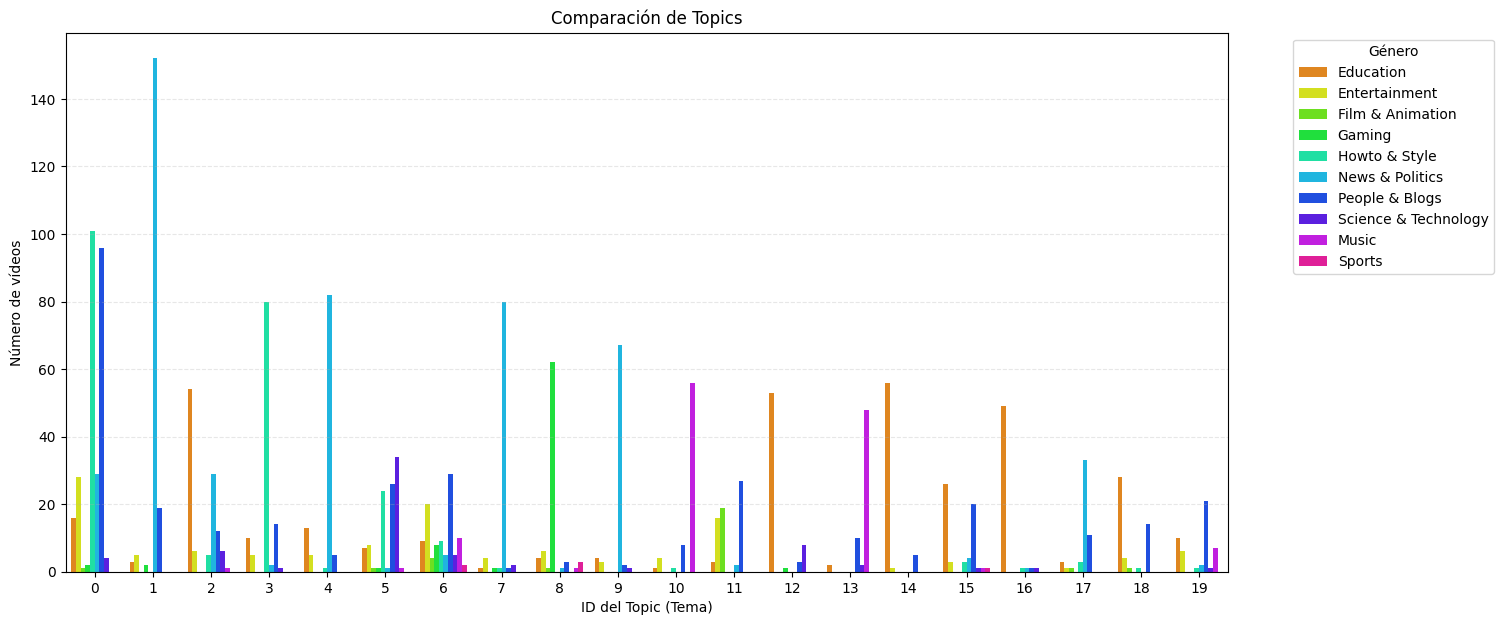

In [50]:
generos_a_comparar = dicc_bertopic_descripcion.keys()

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_descripcion, generos_a_comparar, "Descripcion")
plt.show()


Aquí repetimos el patrón observado en títulos, hay tópicos dominados por géneros en su amplia mayoría. Los 20 tópicos más representativos estan dominados por Education, News & Politics, Music. Solamente Sports o Entertainment parecen no tener una representación significativa. 

## Subtítulos

In [51]:

topic_model_subtitulos, df_bertopic_subtitulos, temas_bertopic_subtitulos  = utils.analizar_bertopic_dict(diccionario_generos_fil, "Descripcion")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [52]:
dicc_bertopic_subtitulos= utils.division_generos(df_bertopic_subtitulos)

<Figure size 1000x600 with 0 Axes>

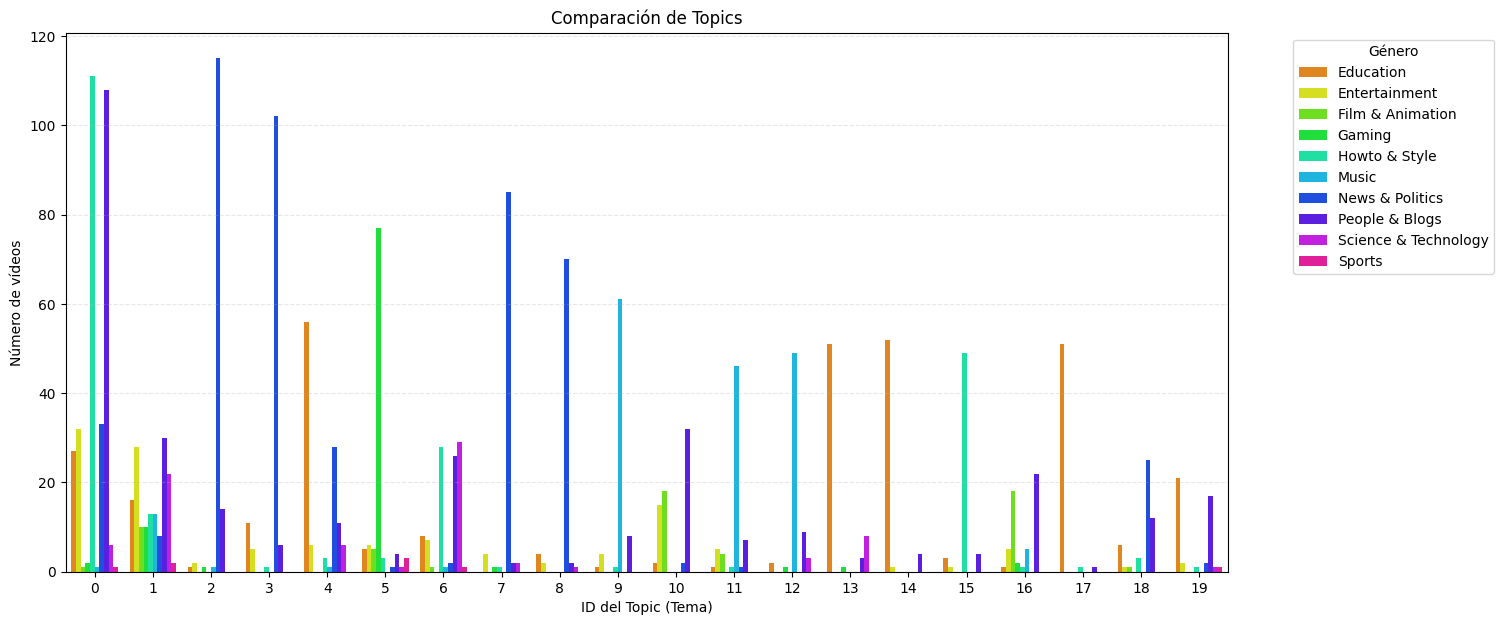

In [53]:
generos_a_comparar = dicc_bertopic_subtitulos.keys()

plt.figure(figsize=(10,6))
utils.graficar_bertopic_multiple(df_bertopic_subtitulos, generos_a_comparar, "Subtitulos")
plt.show()

Finalmente aquí repetimos el patrón observado en el resto de gráficas. 